In [1]:
# Hier nichts ändern, nur ausführen!
import sys; sys.path.append("../code"); from setup_AB3 import *; setup_erfolg();

# Arbeitsblatt 3 | Bildbearbeitung mit dem Quantencomputer

Im Folgenden schauen wir uns ein paar Möglichkeiten an, wie wir Bilder mit Hilfe eines Quantencomputers bearbeiten können und welche Effekte das hat.

## 1) Reduktion der Werte

Wir haben im letzten Arbeitsblatt gesehen, wie wir Bilder in einem Computer abbilden. Auf einem Quantencomputer funktioniert das ähnlich. Wir legen unsere Werte allerdings nicht in Bits ab, sondern in sogenannten Qubits.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Wie viele Bits werden benötigt um einen Farbwert zu speichern? </h3>
  <p>Im letzten Arbeitsblatt haben wir gelernt, dass ein Farbwert im Wertebereich von <code>0</code> bis <code>255</code> liegt. In einem Bit können nur zwei Werte, <code>0</code> und <code>1</code>, gespeichert werden. Was meinst du, wieviele Bits sind nötig, um einen Farbwert zu speichern?</p>
</div>

In [2]:
# Hier nichts ändern, nur ausführen!
show_bit_prompt()

Output()

Output()

Diese Anzahl Werte kriegen wir heute schon locker auf einen Quantencomputer, aber weniger wären trotzdem besser. Denn weniger Werte bedeuten immer weniger Rechenaufwand - auf normalen Computern und auf Quantencomputern.

In [3]:
show_qubit_slider()

interactive(children=(IntSlider(value=2, description='Qubit Anzahl', max=8), Output()), _dom_classes=('widget-…

<div id="information" class="alert alert-success">
  <h2><i class="fas fa-info" style="font-size:36px"></i> </h2>
  <p>Was genau ist da gerade eben passiert? 
  
  Zunächst einmal hast du über die Anzahl der Qubits definiert, auf wieviele Bits du die einzelnen Farbwerte abbilden möchtest.
  
  Stell dir vor, du willst einer Freundin eine zweistellige Zahl übermitteln, also zB. <code>63</code>. Dafür darfst du ihr aber nur eine einstellige Zahl mitteilen. Wie könntest du das machen? 
  
  Nun - perfekt geht das nicht. Man kann nicht eine Nachricht schicken, die mehr Infos hat als Stellen. Man kann aber nah drankommen. Du könntest deine Zahl zum Beispiel auf die nächste Zehnerstelle runden und deiner Freundin dann die Zehnerstelle nennen, also <code>63</code> auf <code>60</code> runden und deiner Freundin dann die <code>6</code> nennen. Diese müsste dann <code>6</code> mit <code>10</code> multiplizieren und wüsste: "Die Zahl war ungefähr <code>60</code>". 

  Das ist natürlich nicht perfekt. Informationen gehen verloren, aber statt <code>2</code> Ziffern musst du nur noch eine übergeben - stell dir das mal im ganz großen Stil vor. 
  
  Genau das ist gerade eben passiert, nur eben auf Basis von Bits. So sparen wir für jeden Pixelwert etliche Ziffern bzw. Bits - das sind Millionen für ein ganzes Bild! Das Bild sieht nach dieser Reduktion ein bisschen anders aus, denn auch hier gehen ja Informationen und damit Details verloren. Wenn du das ganze noch besser verstehen willst, frag uns einfach :)

  Wenn du mehr Qubits angegeben hast, gehen weniger Informationen verloren, weil wir erlauben mehr zu übergeben. Bei `8` Qubits gibt es keinen Informationsverlust, dann dauert die Bildbearbeitung aber lange.</p>
</div>

## 2) Kodierung auf dem Quantencomputer

Ein wesentlicher Bestandteil zum Bedienen von den Quantencomputern, wie wir sie heute verwenden werden, ist die Definition des Quanten-Schaltkreises (Quantum Circuit).
Dieser gibt an, wie die Information auf dem Quantencomputer verarbeitet werden. Du kannst dir das wie eine mathematische Formel vorstellen.
In unserem Fall, wäre ein Qubit der Zustand und jede Operation (jedes Gate), das wir darauf anwenden, verändert diesen Zustand.

Lass uns mal ein ganz einfaches Beispiel machen. Wir erstellen ein Circuit mit nur einem einzigen Qubit. Ein Qubit ist zu Beginn immer im Zustand `0`. Wir wollen es jetzt in den Zustand `1` ändern. 
Das funktioniert mit einem sogenannten `x` Gate, das wir einfach auf `quantum_circuit` aufrufen. Führe die folgende Zelle mal aus. Mit der Funktion `draw()` können wir uns anzeigen lassen, wie das Circuit dann aussieht. 

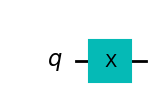

In [4]:
# Wir erstellen unser Circuit. Das soll 1 Qubit haben
quantum_circuit = QuantumCircuit(1)

# Wir fügen das x Gate auf Qubit 0 hinzu
# (wir fangen wieder bei 0 an zu zählen)
quantum_circuit.x(0)
quantum_circuit.draw(output="mpl")

Super Sache! Aber woher wissen wir denn nun ob das Qubit wirklich verändert wurde?
Nun dazu müssen wir es messen. Das geschieht durch anhängen eines Messoperators. Dieser macht aus dem Qubit-Zustand wieder `0` oder `1`. Wir können allgemein beliebig viele Qubits messen, indem wir `measure_all()` auf dem Circuit aufrufen.

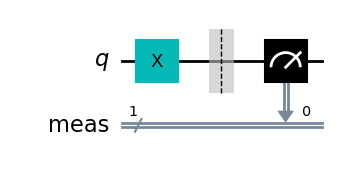

In [5]:
quantum_circuit = QuantumCircuit(1)
quantum_circuit.x(0)
quantum_circuit.measure_all()
quantum_circuit.draw(output="mpl")

Jetzt müssen wir das ganze einmal ausführen und können uns das Ergebnis direkt anzeigen lassen.

In [6]:
result = get_result(quantum_circuit)

print(result)

{'1': 100}


Das Ergebnis sagt aus, dass der Zustand `1` in 100% der Fälle gemessen wurde.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Erstelle einen Quantenschaltkreis für ein 1-Bit RGB-Bild </h3>
  <p>Gerade eben haben wir uns einen Quantenschaltkreis angeschaut, der nur einen Farbkanal abbilden kann. Erstelle nun bitte einen Schaltkreis, der ein RGB-Bild darstellen kann.</p>
</div>

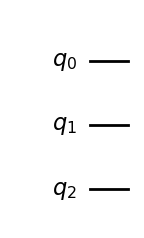

In [8]:
# Erstelle zunächst deinen Circuit mit der entsprechenden Anzahl Qubits
# Die Anzahl der Qubits ist abhängig von den Bits und den Farbkanälen
quantum_circuit_2a = QuantumCircuit(3)

# Lasse dir deinen Circuit zur Kontrolle anzeigen
quantum_circuit_2a.draw(output="mpl")

## 3. Bildverarbeitung mit dem Quantencomputer

Wir beginnen nun ein paar Operationen auf dem Bild mit Hilfe des Quantencomputers durchzuführen. Methodisch werden wir dabei so vorgehen, dass wir uns jeden Pixel und jeden Farbkanal einzeln anschauen werden. Wir brauchen also im Circuit nicht explizit dafür sorgen, dass die entsprechenden Werte für jeden Farbkanal kodiert werden. Unser Quanten Circuit muss also auf jedes Pixel und auf jeden Kanal (Rot, Grün, Blau) des Bildes angewandt werden.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> a) Erzeuge eine umgekehrte Katze </h3>
  <p>Dann lass uns mal schauen, ob wir das bisherige Wissen über Quanten Computer schon auf Bilder übertragen können.
Wir wissen ja jetzt, dass ein <code>X</code> Gate den Zustand unseres Qubits einmal umkehrt.
Das können wir nutzen um unser Katzenbild zu invertieren, genauso wie wir es im <a href="./Image_Basics.ipynb">Notebook zur Bildverarbeitung</a> gemacht haben.</p>
<hr/>
<details>
  <summary>Ein paar kleine Tipps gefällig?</summary>
  <ul>
    <li>Schreibe eine <code>for</code>-Schleife, in der du auf jedes verfügbare Qubit ein <code>X</code> Gate anwendest</li>
    <li>In deiner <code>for</code>-Schleife kannst du die Funktion <code>range()</code> nutzen, damit du über die Anzahl der Qubits iterieren kannst</li>
  </ul>
</details>
</div>

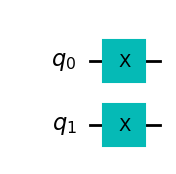

In [9]:
quantum_circuit_3a = QuantumCircuit(my_qubit_count())

# --- Ab hier dein Code ---
for qubit in range(my_qubit_count()):
    quantum_circuit_3a.x(qubit)
# -------------------------

quantum_circuit_3a.draw(output="mpl")

<div id="information" class="alert alert-success">
  <h2><i class="fas fa-info" style="font-size:36px"></i> </h2>
  <p>Da unser Quanten Circuit aber jedesmal identisch ist, können wir uns die Abbildung (Mapping) der einzelnen Bits von dem Eingangs- auf den Ausgangswert speichern und dann auf das gesamte Bild anwenden.
  Das spart uns einiges an Rechenzeit auf dem Quantencomputer!
  
  Dazu erzeugen wir zuerst ein <code>Mapping</code> (dabei wird der Quantencomputer genutzt) und anschließend wenden wir dieses auf das gesamte Bild oder einen Bildausschnitt unseres Katzenbildes an. Welche Pixel wir genau transformieren werden, ist in <code>my_pixels_to_transform()</code> verfügbar.</p>
</div>

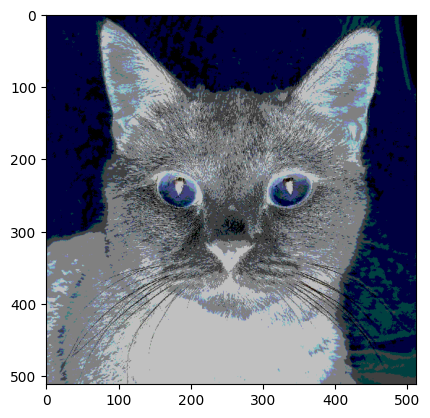

In [10]:
mapping = create_mapping(quantum_circuit_3a)
q_image_3a = convert_image(my_qubit_count(), image, mapping, my_pixels_to_transform())
imshow(q_image_3a);

Perfekt! Welches Mapping haben wir denn jetzt mit dem Quantencomputer erzeugt? Das können wir uns mit einer Funktion anzeigen lassen, die wir für dich geschrieben haben. Führe dafür mal die folgende Codezeile aus.

In [11]:
print_mapping(mapping)

00 wird auf 11 abgebildet
01 wird auf 10 abgebildet
10 wird auf 01 abgebildet
11 wird auf 00 abgebildet


Es wird also quasi aus jeder $0$ eine $1$ gemacht. Das passt ja: auf deinem Circuit befinden sich auf jedem Qubit ein `x` Gate, das den Wert ändert. 

Wahrscheinlich hast du es schon gemerkt, aber Qubits sind für einen Quantencomputer das, was Bits für unsere klassischen Computer sind; Die kleinste Informationseinheit die wir mit diesen Geräten abbilden können.
Das Spannende ist nun, mit so einem Qubit kann man viel mehr machen, als wir es mit einem klassischen Bit könnten!

Ein Qubit kann nicht nur entweder $0$ oder $1$ sein, sondern **beides gleichzeitig** mit einer gewissen Wahrscheinlichkeit. Klingt ein bisschen komisch?

Stell dir jetzt einfach vor, im Klassischen haben wir nur einen Strich an dessen Endpunkten entweder $0$ oder $1$ steht. Genau diese, und nur diese beiden Zustände können wir einnehmen.
Im Quantencomputing können wir mit Hilfe der Qubits jeden erdenklichen Punkt auf der Oberfläche einer Kugel einnehmen und das als Zustand definieren. 

![Bit und Qubit Darstellung](../images/qbits.png)

Wie du beim Anschauen der invertierten Katze lernen konntest, können wir auf dem Nordpol unseres Qubits den Wert $0$ abbilden und auf Südpol den Wert $1$. Beim Messen des Qubits bekommen wir in dieser Ebene dann entweder den Wert $0$ oder den Wert $1$. 

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> b) Superposition </h3>
  <p>Was meinst du, was passiert, wenn wir den Zustand des Qubits so ändern, dass sich dieser genau zwischen <code>0</code> und <code>1</code>, also genau auf dem Äquator, befindet? Wie hoch ist die Wahrscheinlichkeit <code>0</code> zu messen und wie hoch ist die Wahrscheinlichkeit <code>1</code> zu messen?</p>
  <img src="../images/plusstate.png"/>
<hr/>
<details>
  <summary>Ein paar kleine Tipps gefällig?</summary>
  <ul>
    <li>Die Position auf der Kugel bestimmt die Wahrscheinlichkeit, mit der du den Wert <code>0</code> oder <code>1</code> misst.</li>
    <li>Wenn du den Zustand auf dem Nord- oder Südpol definierst, hast du jeweils 100% Wahrscheinlichkeit die <code>0</code> oder die <code>1</code> zu messen. Die Wahrscheinlichkeit für den jeweils anderen Pol liegt dann bei 0%.</li>
    <li>Lass dich nicht von den Zuständen <code>+</code> und <code>-</code> verwirren. Aber frag uns gern danach :)</li>
  </ul>
</details>
</div>

In [12]:
# Nur ausführen, nicht ändern!
prompt_3b()

Output()

Output()

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> c) Erzeuge eine zufällige Katze </h3>
  <p>Lass uns doch gleich mal praktisch ausprobieren, was passiert, wenn wir unseren Zustand auf den Äquator setzen. Dazu gibt es das sogenannte <i>Hadamard-Gate</i>. Das kannst du mit <code>h</code> in deinem Circuit erzeugen. Und da sich das Qubit beim Messen entscheiden muss, ob es <code>0</code> oder <code>1</code> ist und das davon abhängt, wie weit der Zustand von den Polen entfernt ist, sehen wir hoffentlich gleich, einen zufälligen Effekt.</p>
  <img src="../images/plusstate.png"/>
<hr/>
<details>
  <summary>Ein paar kleine Tipps gefällig?</summary>
  <ul>
    <li>Das Hadamard-Gate <code>h</code> wird genauso verwendet, wie das <code>x</code> Gate.</li>
  </ul>
</details>
</div>

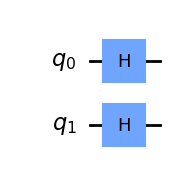

In [13]:
quantum_circuit_3c = QuantumCircuit(my_qubit_count())

# --- Ab hier dein Code ---
for qubit in range(my_qubit_count()):
    quantum_circuit_3c.h(qubit)
# -------------------------

quantum_circuit_3c.draw(output="mpl")

Führe den folgenden Code einfach ein paar mal aus und beobachte wie sich das Mapping, bzw. das Bild verändert.

00 wird auf 11 abgebildet
01 wird auf 00 abgebildet
10 wird auf 10 abgebildet
11 wird auf 00 abgebildet


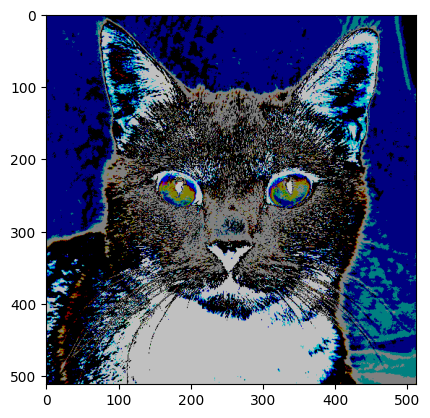

In [14]:
mapping = create_mapping(quantum_circuit_3c)
q_image_3c = convert_image(my_qubit_count(), image, mapping, my_pixels_to_transform())

print_mapping(mapping)

imshow(q_image_3c);

Klasse! Jetzt weißt du schon, dass so ein Qubit mehr Zustände annehmen kann, als ein klassisches Bit.
Es gibt aber noch mehr! Bisher war immer die Rede von Operationen auf einzelnen Qubits. Wir haben im Quantencomputing aber auch die Option Operationen auf zwei oder mehr Qubits auszuführen.

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> d) Erzeuge eine vertauschte Katze </h3>
  <p>Eins der Gates, die auf zwei Qubits arbeitet, ist das sogenannte SWAP-Gate. Dieses ermöglicht es, zwei Qubits miteinander zu vertauschen. Damit können wir beispielsweise die Farbwerte unserer Farbkanäle tauschen. Das heißt, dass wir nun wieder einen Circuit erzeugen, der <code>3</code> mal so viele Qubits hat, da wir alle drei Farbkanäle nutzen wollen.<br/>
  Deine Aufgabe: Tausche die Qubits des Rot- und Grünkanals.</p>
<hr/>
<p>Wir stellen dir die Funktion <code>create_rgb_qubits(...)</code> zur Verfügung. Diese erstellt die notwendigen Qubits für deinen Circuit und beachtet dabei die von dir gewählte Anzahl an Qubits und die Anzahl der Farbkanäle.</p>
<hr/>
<details>
  <summary>Ein paar kleine Tipps gefällig?</summary>
  <ul>
    <li>Das SWAP-Gate <code>swap</code> ist eine Funktion, die zwei Parameter erwartet: Die Nummern der zwei Qubits, die vertauscht werden sollen</li>
    <li>Beachte, dass wir auch hier mit dem Zählen wieder bei 0 beginnen</li>
    <li>Führe den Circuit gern erstmal ohne deine Implementierung aus, dann kannst du abzählen, welche Qubits du vertauschen möchtest</li>
  </ul>
</details>
</div>

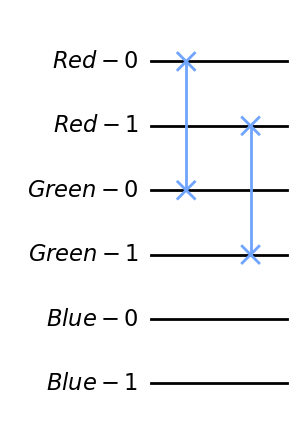

In [15]:
rgb_qubits = create_rgb_qubits(my_qubit_count())
quantum_circuit_3d = QuantumCircuit(*rgb_qubits)

# --- Ab hier dein Code ---
for qubit in range(my_qubit_count()):
    quantum_circuit_3d.swap(qubit, my_qubit_count() + qubit)
# -------------------------

quantum_circuit_3d.draw(output="mpl")

Jetzt wieder der Code, um das Mapping zu erzeugen und es auf das Bild anzuwenden.
Tausche auch gern andere Farbkanäle miteinander und schaue wie sich das Bild verändert.

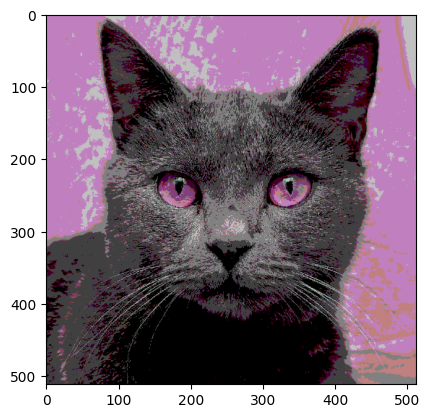

In [16]:
mapping = create_rgb_mapping(quantum_circuit_3d)
q_image_3d = convert_rgb_image(my_qubit_count(), image, mapping, my_pixels_to_transform())
imshow(q_image_3d);

Eine weitere spannende Eigenschaft, die wir im Quantencomputing nutzen können, sind sogenannte Verschränkungen. Verschränkung bedeutet, dass zwei Qubits so miteinander verbunden sind, dass das, was mit dem einen passiert, sofort auch das andere beeinflusst. Unabhängig davon, wie weit die beiden auseinander liegen. Du kannst dir das wie ein magisches Band vorstellen, dass beide Qubits zusammenhält. Zum Beispiel können wir zwei Qubits so miteinander verschänken, dass sobald eins gemessen wird, das andere sofort den gleichen Wert annimmt.

Anhand zweier Farbwürfel kannst du dir das so vorstellen, dass wenn du einen von beiden würfelst und zum Beispiel rot oben landet, dann wird der zweite Würfel auch sofort rot, ohne dass du ihn überhaupt angefasst hast. Das ist genau wie Verschränkung: Die beiden Würfel verhalten sich immer zusammen, egal wie weit sie auseinander liegen. Dieses Phänomen gibt Quantencomputern ihre außergewöhnliche Rechenleistung, da Qubits zusammen Berechnungen machen können, die klassische Bits nicht schaffen.

Frag uns einfach, wenn du mehr dazu wissen möchtest!

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> e) Erzeuge eine verschränkte Katze </h3>
  <p>Um Verschränkungen zu erzeugen, kodieren wir zunächst wieder unsere Farbwerte und setzen ein Hadamard-Gate sowie ein oder mehrere zwei-Qubit-Gates ein. Durch das Kombinieren von Hadamard-Gates und kontrollierten zwei-Qubit-Gates, z.B. <code>cx</code> entsteht ein verschränkter Zustand, der die Farbe unseres Bildes als gemeinsam genutzte Quanteneigenschaft speichert.
  Deine Aufgabe: Verschränke die Qubits des Rot- und Grünkanals.</p>
<hr/>
  <a href="../help/tipps_AB3_3e.ipynb"><i class="fas fa-life-ring" style="font-size:20px"></i> &nbsp;Tipp</a> <span style="margin-right: 20px;"></span>   <!-- Link zum Tipp anpassen oder Zeile löschen-->
  <a href="../help/zusatz_AB3_3e.ipynb"><i class="fas fa-puzzle-piece" style="font-size:20px"></i> &nbsp; Zusatzaufgabe</a> 
</div>

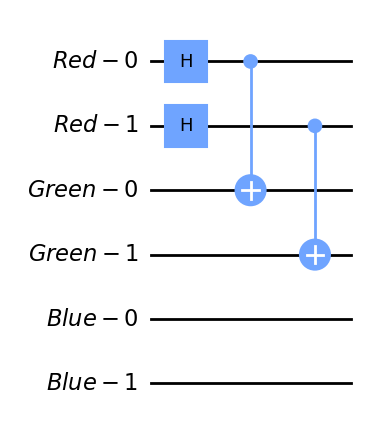

In [17]:
rgb_qubits = create_rgb_qubits(my_qubit_count())
quantum_circuit_3e = QuantumCircuit(*rgb_qubits)

# --- Ab hier dein Code ---
for qubit in range(my_qubit_count()):
    quantum_circuit_3e.h(qubit)
    quantum_circuit_3e.cx(qubit, my_qubit_count() + qubit)
# -------------------------

quantum_circuit_3e.draw(output="mpl")

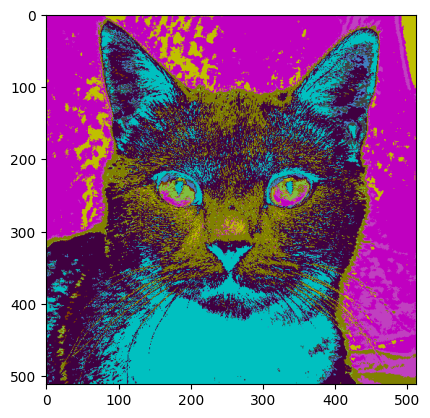

In [18]:
mapping = create_rgb_mapping(quantum_circuit_3e)
q_image_3e = convert_rgb_image(my_qubit_count(), image, mapping, my_pixels_to_transform())
imshow(q_image_3e);

Durch das gezielte Anwenden von Hadamard- und kontrollierten Gates (z.B. CNOT) erzeugst du Verschränkung zwischen den Farbkomponenten. Der Status deines Circuits trägt die Farbe nicht mehr als getrennte Bits, sondern als **gemeinsame Quanteninformation**.

Du lernst jetzt noch eine weitere tolle Eigenschaft von Quantencomputern kennen. Jede Operation die wir auf einem solchen Gerät ausführen, ist (bis auf die Messung am Ende) umkehrbar!
Das bedeutet, wir können das Circuit von gerade eben einfach nehmen, umdrehen (`inverse()`) und an das Original anhängen (`.compose()`).
Das Ergebnis sollte im Idealfall ein Circuit sein, das nichts an unserem Bild ändert, ... oder?

<div id="exercise" class="alert alert-info">
  <h3><i class="fa fa-laptop" style="font-size:28px"></i> <br><br> f) Die verrauschte Katze </h3>
  <p>Erstelle einen weiteren Circuit zur Bearbeitung deines Bildes und hänge den invertierten Circuit an den Circuit an, um dir das Ergebnis anzuschauen.</p>
  <p>Nimm am besten den Circuit aus Aufgabe 3d, <code>quantum_circuit_3e</code>. Vielleicht erinnerst du dich, dass wir in diesem Circuit nur die Farbkanäle getauscht haben? Wenn wir diese also wieder zurück tauschen, sollte sich ja tatsächlich nichts ändern.</p>
<hr/>
<ul>
  <li>Die Funktion <code>compose()</code> rufst du an deinem aktuellen Circuit auf und übergibst als Parameter den Circuit aus Aufgabe 3e sowie den Parameter <code>inplace=True</code></li>
  <li>Die Funktion <code>inverse()</code> kannst du an einem Circuit aufrufen. Sie benötigt keine weiteren Parameter.</li>
  <li>Mit der Funktion <code>barrier()</code> kannst du optisch die unterschiedlichen Teile deines Circuits voneinander trennen. Die Funktion wird an deinem aktuellen Circuit aufgerufen wie beim Hinzufügen von Gates.</li>
</ul>
</div>

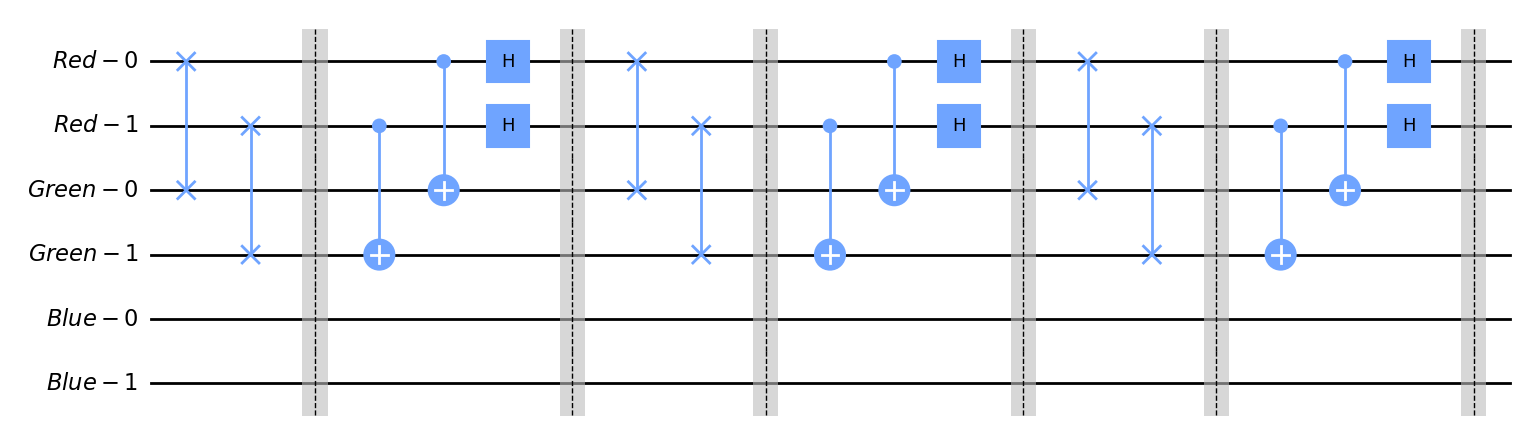

In [20]:
REPS = 3  # Wie oft du deinen Circuit wiederholen willst

rgb_qubits = create_rgb_qubits(my_qubit_count())
overall_quantum_circuit = QuantumCircuit(*rgb_qubits)

for i in range(REPS):
    # --- Ab hier dein Code ---
    overall_quantum_circuit.compose(quantum_circuit_3d, inplace=True)
    overall_quantum_circuit.barrier()
    overall_quantum_circuit.compose(quantum_circuit_3e.inverse(), inplace=True)
    overall_quantum_circuit.barrier()
    # -------------------------

overall_quantum_circuit.draw(output="mpl")

Bisher liefen unsere Simulation und Berechnung in einer "idealen" Welt. Das heißt, wir hatten keine Störeinflüsse von außen und die Simulationen lieferten stets das Ergebnis, das wir mathematisch auch erwarten würden. Heutzutage sind Quantencomputer leider noch alles andere als perfekt. Um uns das mal genauer anzuschauen, übergeben wir nun ein sogenanntes `backend`, welches ein detailgetreues Modell eines echten Quantencomputers ist.
Dieses Modell wird in der Simulation dann verwendet um das Verhalten des echten Computers nachzubilden.

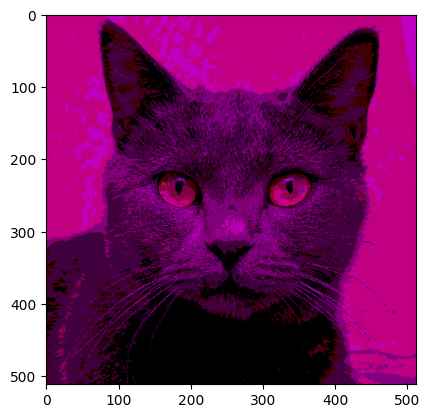

In [21]:

backend = FakeMelbourne()

mapping = create_rgb_mapping(overall_quantum_circuit, backend=backend)
q_image_3f = convert_rgb_image(my_qubit_count(), image, mapping, my_pixels_to_transform())

# print_mapping(mapping)

imshow(q_image_3f);

Huch! Da ist wohl was schiefgegangen, oder?
Nein, leider nicht. Die Quantencomputer sind in der Tat sehr fehleranfällig heutzutage.

Aber Zeiten ändern sich! Die Leute von IBM, deren Backend wir gerade genutzt haben, und viele andere Forschende auf der Welt, versuchen Quantencomputer so schnell wie möglich fehlerfrei und vor allem größer zu bauen.

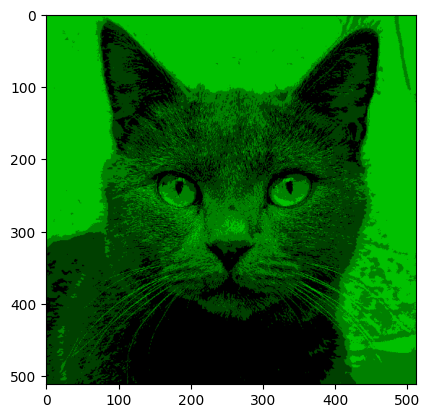

In [22]:
# Das zeigt dir die tatsächlichen Fehler,
# die durch Rauschen erzeugt werden
imshow(my_reduced_image()-q_image_3f);

<hr>

## Zusammenfassung des dritten Arbeitsblattes

Auf dem dritten Arbeitsblatt haben wir einige der Grundlagen des Quantencomputing kennengelernt und beispielhaft für die Bildbearbeitung eingesetzt. Wir haben dafür folgenden Themen bearbeitet:

1. **Reduktion der Werte:** Wir haben damit gestartet, die Pixelwerte zu reduzieren, um für unsere Simulationen mit weniger Qubits arbeiten zu können. Dies erspart uns einiges an Wartezeit für unsere Simulationen, sorgt aber für schlechtere Ausgabequalität.

2. **Kodierung auf dem Quantencomputer:** Daraufhin haben wir uns angeschaut, wie wir mit sogenannten Gates die Pixelwerte auf unseren Qubits kodieren. 

3. **Bildverarbeitung auf dem Quantencomputer:** Im Kontext der Bearbeitung von Bildern haben wir die Phänomene Superposition und  Verschränkung sowie die Umkehrbarkeit von Circuits kennengelernt. Außerdem haben wir 1-Qubit- und 2-Qubit-Gates kennengelernt und ganz nebenher viele tolle, einmalige Katzenbilder erzeugt.

<hr>

## Diskussion im Plenum <i class="fa fa-comments-o" style="font-size:36px"></i> 
**Wir werden die bisherigen Ergebnisse gemeinsam diskutieren!** <br>
Dies war das letzte Arbeitsblatt, aber vielleicht möchtest du noch ein paar der Zusatzaufgaben erledigen?